In [1]:
import sys
from pathlib import Path
import json

import torch
from torch.nn import Sequential, Conv2d, ReLU, Module, MaxPool2d, Linear, Flatten, BatchNorm2d, Dropout2d, Dropout
import torch.optim as optim
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from tqdm.auto import tqdm
import pandas as pd


from src.data.dataset import DataLoader
from src.data.dataset import create_data_loaders

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060


In [4]:
train_loader, validation_loader, test_loader = create_data_loaders()

In [5]:
PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

In [6]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(train_loader.dataset.class_to_idx)

torch.Size([32, 3, 128, 128])
torch.Size([32])
{'cats': 0, 'dogs': 1}


In [5]:
conv_1 = Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=3,
    padding=1
)

conv_1_output = conv_1(images)
conv_1_output.shape

torch.Size([32, 32, 128, 128])

32  - batch size

32  - feature maps

128 - height

128 - width

In [6]:
relu = ReLU()

relu_output = relu(conv_1_output)

print(relu_output.shape)

torch.Size([32, 32, 128, 128])


In [7]:
pool = MaxPool2d(kernel_size=2)

pool_output = pool(relu_output)

print(pool_output.shape)

torch.Size([32, 32, 64, 64])


In [8]:
def conv_block_x(imgs):
    conv = Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
    )

    relu_x = ReLU()
    pool_x = MaxPool2d(kernel_size=2)

    output = conv(imgs)
    print(output.shape)

    output = relu_x(output)
    print(output.shape)

    output = pool_x(output)
    print(output.shape)

    return output

In [9]:
conv_block_x(images)

torch.Size([32, 32, 128, 128])
torch.Size([32, 32, 128, 128])
torch.Size([32, 32, 64, 64])


tensor([[[[6.4206e-01, 6.4206e-01, 6.4206e-01,  ..., 6.4206e-01,
           6.4206e-01, 6.4206e-01],
          [7.5267e-02, 7.5267e-02, 7.5267e-02,  ..., 2.5816e-02,
           7.5267e-02, 2.1770e-01],
          [7.5267e-02, 3.6290e-03, 0.0000e+00,  ..., 0.0000e+00,
           7.5267e-02, 2.1770e-01],
          ...,
          [7.5267e-02, 7.5267e-02, 3.6581e-01,  ..., 2.8517e-01,
           2.8403e-01, 3.5346e-01],
          [7.5267e-02, 7.5267e-02, 4.9265e-01,  ..., 7.5267e-02,
           7.5267e-02, 2.1770e-01],
          [7.5267e-02, 7.5267e-02, 2.2530e-01,  ..., 7.5267e-02,
           7.5267e-02, 2.1770e-01]],

         [[1.0241e+00, 1.0241e+00, 1.0241e+00,  ..., 1.0241e+00,
           1.0241e+00, 1.1693e+00],
          [1.0241e+00, 1.0241e+00, 1.0241e+00,  ..., 9.1828e-01,
           1.0241e+00, 1.1693e+00],
          [1.0241e+00, 9.5129e-01, 3.3602e-01,  ..., 8.5640e-01,
           1.0241e+00, 1.1693e+00],
          ...,
          [1.0241e+00, 1.0241e+00, 1.2060e+00,  ..., 8.9605

In [10]:
class BaseCNN(Module):

    def __init__(self):
        super().__init__()

        self.features = Sequential(
            # First convolutional layer.
            #
            # in_channels=3:
            # The input image has three color channels:
            # red, green, and blue.
            #
            # out_channels=32:
            # The layer learns 32 different filters.
            # Each filter produces one feature map.
            #
            # kernel_size=3:
            # Each filter has a spatial size of 3 x 3 pixels.
            #
            # padding=1:
            # Adds one row and one column of padding around the image.
            # This preserves the spatial dimensions:
            #
            # 128 x 128 -> 128 x 128
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),

            # Applies the ReLU activation function.
            #
            # ReLU replaces every negative value with zero:
            #
            # ReLU(x) = max(0, x)
            #
            # It introduces non-linearity and allows the network
            # to learn more complex patterns.
            #
            # The tensor shape does not change:
            #
            # [batch_size, 32, 128, 128]
            ReLU(),

            # Reduces the height and width by taking the maximum
            # value from every 2 x 2 region.
            #
            # The number of channels remains unchanged.
            #
            # Shape:
            #
            # [batch_size, 32, 128, 128]
            # ->
            # [batch_size, 32, 64, 64]
            MaxPool2d(kernel_size=2),

            # Second convolutional layer.
            #
            # in_channels=32:
            # The input now contains 32 feature maps produced
            # by the previous convolutional layer.
            #
            # out_channels=64:
            # This layer learns 64 new filters and produces
            # 64 feature maps.
            #
            # kernel_size=3 and padding=1 preserve the current
            # spatial dimensions:
            #
            # 64 x 64 -> 64 x 64
            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),

            # Applies ReLU after the second convolutional layer.
            #
            # Negative values are replaced with zero.
            #
            # Shape remains:
            #
            # [batch_size, 64, 64, 64]
            ReLU(),

            # Applies another 2 x 2 max pooling operation.
            #
            # Height and width are divided by two:
            #
            # [batch_size, 64, 64, 64]
            # ->
            # [batch_size, 64, 32, 32]
            MaxPool2d(kernel_size=2),
        )

        # The classification part of the network.
        # These layers use the extracted visual features
        # to decide whether the image contains a cat or a dog.
        self.classifier = Sequential(

            # Converts the 3D feature maps into a one-dimensional vector.
            #
            # Before flattening:
            #
            # [batch_size, 64, 32, 32]
            #
            # Each image contains:
            #
            # 64 * 32 * 32 = 65,536 values
            #
            # After flattening:
            #
            # [batch_size, 65,536]
            Flatten(),

            # Fully connected layer.
            #
            # in_features=64 * 32 * 32:
            # Receives the 65,536 flattened feature values.
            #
            # out_features=128:
            # Produces a smaller representation containing
            # 128 learned values.
            #
            # Shape:
            #
            # [batch_size, 65,536]
            # ->
            # [batch_size, 128]
            Linear(in_features=64 * 32 * 32, out_features=128),

            # Applies ReLU to the output of the first Linear layer.
            #
            # Negative values are replaced with zero.
            #
            # Shape remains:
            #
            # [batch_size, 128]
            ReLU(),

            # Final classification layer.
            #
            # in_features=128:
            # Receives the 128 values from the previous layer.
            #
            # out_features=2:
            # Produces one score for each class:
            #
            # output[:, 0] -> cat score
            # output[:, 1] -> dog score
            #
            # The output values are called logits.
            # They are not probabilities yet.
            #
            # Shape:
            #
            # [batch_size, 128]
            # ->
            # [batch_size, 2]
            Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        """
        Defines how the input tensor passes through the network.

        Parameters
        ----------
        x: A batch of images with shape:
        [batch_size, 3, 128, 128]

        Returns
        -------
        x: Raw class scores with shape:
        [batch_size, 2]
        """
        x = self.features(x)
        x = self.classifier(x)

        return x

In [11]:
model = BaseCNN()

In [12]:
print(model)

BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [13]:
images, labels = next(iter(train_loader))

outputs = model(images)

print(f"Input shape: {images.shape}")
print(f"Output shape: {outputs.shape}")

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 2])


In [14]:
outputs = model(images)

In [15]:
print(outputs)

tensor([[-0.0349, -0.0307],
        [-0.0534, -0.0637],
        [-0.0181, -0.0349],
        [-0.0284, -0.0278],
        [-0.0411, -0.0339],
        [-0.0239, -0.0255],
        [-0.0641, -0.0236],
        [-0.0165, -0.0306],
        [-0.0259, -0.0202],
        [-0.0407, -0.0401],
        [-0.0258, -0.0601],
        [-0.0127, -0.0450],
        [-0.0543, -0.0367],
        [-0.0461, -0.0253],
        [-0.0343, -0.0324],
        [-0.0486, -0.0299],
        [-0.0378, -0.0622],
        [-0.0398, -0.0219],
        [-0.0563, -0.0324],
        [-0.0437, -0.0523],
        [-0.0305, -0.0310],
        [-0.0388, -0.0346],
        [-0.0446, -0.0174],
        [-0.0484, -0.0387],
        [-0.0071, -0.0278],
        [-0.0275, -0.0246],
        [-0.0363, -0.0228],
        [-0.0467, -0.0238],
        [-0.0403, -0.0281],
        [-0.0374, -0.0290],
        [-0.0263, -0.0426],
        [-0.0377, -0.0213]], grad_fn=<AddmmBackward0>)


In [16]:
predictions = torch.argmax(outputs, dim=1)
print(predictions)

tensor([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        0, 1, 1, 1, 1, 1, 0, 1])


In [17]:
print(train_loader.dataset.class_to_idx)

{'cats': 0, 'dogs': 1}


In [18]:
print(torch.bincount(predictions))

tensor([11, 21])


In [19]:
loss_function = CrossEntropyLoss()

optimizer = Adam(
    model.parameters(),
    lr=0.001,
)

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1} / {epochs}")

    for images, labels in progress_bar:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = outputs.argmax(dim=1)

        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)
        current_loss = running_loss / total_samples
        current_accuracy = (correct_predictions / total_samples)
        progress_bar.set_postfix(loss=f"{loss.item():.4f}", accuracy=f"{current_accuracy:.4f}")

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = (correct_predictions / total_samples)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Epoch 1/5:   0%|          | 0/547 [00:00<?, ?it/s]

X:\venvs\main_int\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/5 | Loss: 0.6225 | Accuracy: 0.6391


Epoch 2/5:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 2/5 | Loss: 0.5032 | Accuracy: 0.7501


...

Epoch 3/5 | Loss: 0.4583 | Accuracy: 0.7793


Epoch 4/5:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 4/5 | Loss: 0.4298 | Accuracy: 0.8019


Epoch 5/5:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 5/5 | Loss: 0.4096 | Accuracy: 0.8137


In [23]:
model.parameters

<bound method Module.parameters of BaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)>

In [24]:
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

print("Predictions:", predictions[:10])
print("True labels:", labels[:10])

Predictions: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 1])
True labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [25]:
import matplotlib.pyplot as plt


def denormalize_image(image):
    image = image * 0.5 + 0.5
    return image

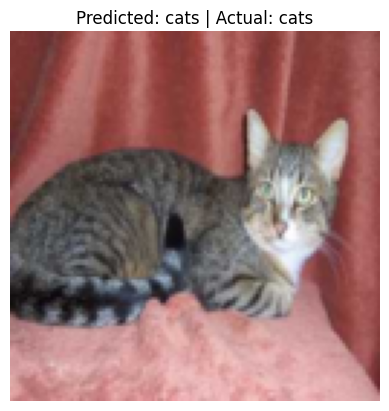

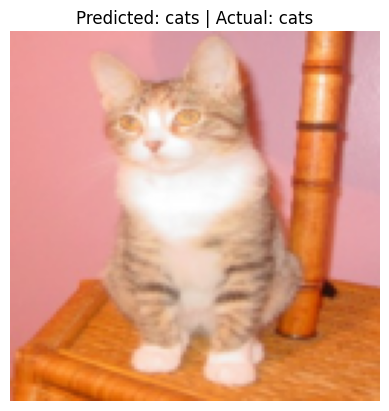

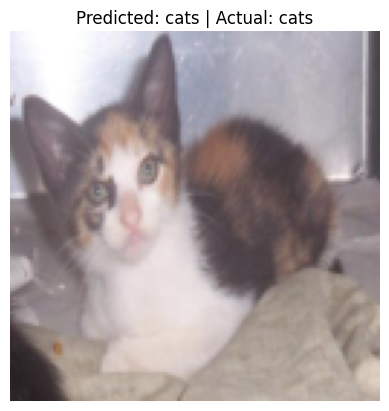

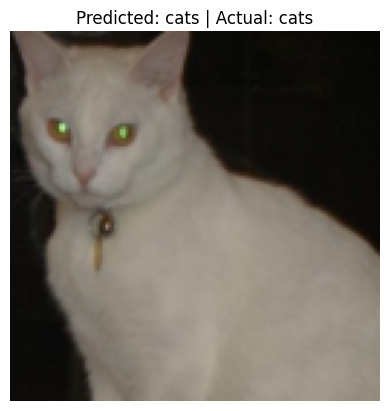

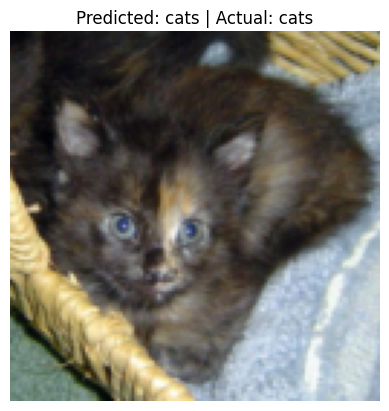

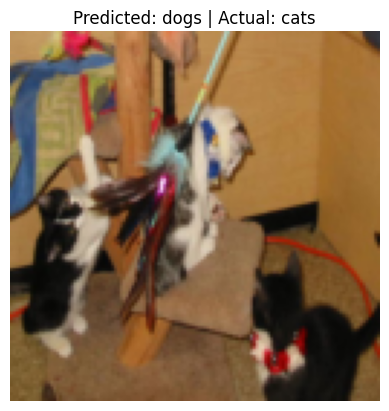

In [26]:
model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

idx_to_class = test_loader.dataset.classes

for index in range(6):
    image = denormalize_image(images[index])
    image = image.permute(1, 2, 0)

    predicted_class = idx_to_class[predictions[index].item()]
    true_class = idx_to_class[labels[index].item()]

    plt.figure()
    plt.imshow(image)
    plt.title(
        f"Predicted: {predicted_class} | Actual: {true_class}"
    )
    plt.axis("off")
    plt.show()

In [28]:
for name, parameter in model.state_dict().items():
    print(name, parameter.shape)

features.0.weight torch.Size([32, 3, 3, 3])
features.0.bias torch.Size([32])
features.3.weight torch.Size([64, 32, 3, 3])
features.3.bias torch.Size([64])
classifier.1.weight torch.Size([128, 65536])
classifier.1.bias torch.Size([128])
classifier.3.weight torch.Size([2, 128])
classifier.3.bias torch.Size([2])


In [34]:
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "04_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "base_cnn.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH,
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\04_models\base_cnn.pth


## Architecture Experiments

The baseline CNN achieved good performance on the internal test dataset but showed weaker generalization on external images.

The goal of this section is to test different CNN architectures and compare their performance using:

- training accuracy
- validation accuracy
- test accuracy
- external images accuracy
- training loss
- validation loss

Each experiment will modify specific parts of the architecture, such as:

- number of convolutional layers
- number of filters
- batch normalization
- dropout
- fully connected layers

#### The results will be compared to determine which architecture generalizes best to unseen images.
---

### Experiment 1: Baseline CNN

**Architecture:**

- 2 convolutional layers
- 32 and 64 filters
- ReLU activation
- Max pooling
- 1 hidden fully connected layer
- No batch normalization
- No dropout

**Purpose:**

This model will be used as the baseline for comparison with the next architectures.

In [ ]:
class BaseCNN(Module):

    def __init__(self):
        super().__init__()

        self.features = Sequential(
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            ReLU(),
            MaxPool2d(kernel_size=2),
        )

        self.classifier = Sequential(
            Flatten(),
            Linear(in_features=64 * 32 * 32, out_features=128),
            ReLU(),
            Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Experiment 2: CNN with Batch Normalization and Dropout

**Changes:**

- added one additional convolutional block
- added batch normalization
- added dropout
- increased the number of filters

**Hypothesis:**

Batch normalization should improve training stability, while dropout should reduce overfitting and improve generalization.

In [11]:
class BatchNormAndDropoutCNN(Module):

    def __init__(self):
        super().__init__()

        self.features = Sequential(
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            BatchNorm2d(num_features=32),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            BatchNorm2d(num_features=64),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            BatchNorm2d(num_features=128),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.3),

            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            BatchNorm2d(num_features=256),
            ReLU(),
            MaxPool2d(kernel_size=3),
            Dropout2d(p=0.3),
        )

        self.classifier = Sequential(
            Flatten(),
            Linear(in_features=256 * 5 * 5, out_features=128),
            ReLU(),
            Dropout(p=0.5),
            Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
model_BatchNormAndDropoutCNN = BatchNormAndDropoutCNN().to(device)

In [13]:
history = []

loss_function = CrossEntropyLoss()

optimizer = Adam(
    model_BatchNormAndDropoutCNN.parameters(),
    lr=0.0001,
)

epochs = 20

for epoch in range(epochs):

    model_BatchNormAndDropoutCNN.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1} / {epochs}",
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_BatchNormAndDropoutCNN(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct_predictions += (predictions == labels).sum().item()
        total_samples += labels.size(0)

        current_accuracy = correct_predictions / total_samples

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{current_accuracy:.4f}",
        )

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct_predictions / total_samples

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "train_accuracy": epoch_accuracy,
    })

history_df = pd.DataFrame(history)

history_df.to_csv(
    "../05_outputs/experiments/batchnorm_dropout_cnn/history.csv",
    index=False,
)

Epoch 1 / 20:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 1/20 | Loss: 0.6624 | Accuracy: 0.6053


Epoch 2 / 20:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 2/20 | Loss: 0.5997 | Accuracy: 0.6759


Epoch 3 / 20:   0%|          | 0/547 [00:00<?, ?it/s]

...

Epoch 18/20 | Loss: 0.3764 | Accuracy: 0.8341


Epoch 19 / 20:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 19/20 | Loss: 0.3734 | Accuracy: 0.8354


Epoch 20 / 20:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 20/20 | Loss: 0.3667 | Accuracy: 0.8432


In [14]:
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "04_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "model_BatchNormAndDropoutCNN.pth"

torch.save(
    model_BatchNormAndDropoutCNN.state_dict(),
    MODEL_PATH,
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\04_models\model_BatchNormAndDropoutCNN.pth


In [15]:
results = {
    "model_name": model_BatchNormAndDropoutCNN.__class__.__name__,
    "epochs": epochs,
    "optimizer": optimizer.__class__.__name__,
    "learning_rate": optimizer.param_groups[0]["lr"],
}

RESULTS_PATH = MODEL_DIR.parent / "05_outputs" / "experiments" / "batchnorm_dropout_cnn" / "results.json"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(RESULTS_PATH, "w") as file:
    json.dump(results, file, indent=4)

print(f"Results saved to: {RESULTS_PATH}")

Results saved to: C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\05_outputs\experiments\batchnorm_dropout_cnn\results.json


### Experiment 3: BatchNorm + Dropout CNN with ReduceLROnPlateau
---
The objective of this experiment is to evaluate whether dynamically reducing the learning rate based on validation loss improves model convergence and validation performance.

In [10]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [11]:
class BatchNormAndDropoutCNN_2(Module):

    def __init__(self):
        super().__init__()

        self.features = Sequential(
            Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            BatchNorm2d(num_features=32),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            BatchNorm2d(num_features=64),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.2),

            Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            BatchNorm2d(num_features=128),
            ReLU(),
            MaxPool2d(kernel_size=2),
            Dropout2d(p=0.3),

            Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            BatchNorm2d(num_features=256),
            ReLU(),
            MaxPool2d(kernel_size=3),
            Dropout2d(p=0.3),
        )

        self.classifier = Sequential(
            Flatten(),
            Linear(in_features=256 * 5 * 5, out_features=128),
            ReLU(),
            Dropout(p=0.5),
            Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [12]:
model_BatchNormAndDropoutCNN_2 = BatchNormAndDropoutCNN_2().to(device)

In [13]:
history = []

loss_function = CrossEntropyLoss()

optimizer = Adam(
    model_BatchNormAndDropoutCNN_2.parameters(),
    lr=0.0001,
)

scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

epochs = 30

for epoch in range(epochs):

    # Training
    model_BatchNormAndDropoutCNN_2.train()

    training_running_loss = 0.0
    training_correct_predictions = 0
    training_total_samples = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{epochs}",
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_BatchNormAndDropoutCNN_2(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        training_running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        training_correct_predictions += (
            predictions == labels
        ).sum().item()

        training_total_samples += labels.size(0)

        current_training_accuracy = (
            training_correct_predictions
            / training_total_samples
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{current_training_accuracy:.4f}",
        )

    training_epoch_loss = (
        training_running_loss / len(train_loader)
    )

    training_epoch_accuracy = (
        training_correct_predictions
        / training_total_samples
    )

    # Validation
    model_BatchNormAndDropoutCNN_2.eval()

    validation_running_loss = 0.0
    validation_correct_predictions = 0
    validation_total_samples = 0

    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_BatchNormAndDropoutCNN_2(images)
            loss = loss_function(outputs, labels)

            validation_running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            validation_correct_predictions += (
                predictions == labels
            ).sum().item()

            validation_total_samples += labels.size(0)

    validation_epoch_loss = (
        validation_running_loss / len(validation_loader)
    )

    validation_epoch_accuracy = (
        validation_correct_predictions
        / validation_total_samples
    )

    # Update the learning rate based on validation loss
    scheduler.step(validation_epoch_loss)

    current_learning_rate = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {training_epoch_loss:.4f} | "
        f"Train Accuracy: {training_epoch_accuracy:.4f} | "
        f"Validation Loss: {validation_epoch_loss:.4f} | "
        f"Validation Accuracy: {validation_epoch_accuracy:.4f} | "
        f"Learning Rate: {current_learning_rate:.6f}"
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": training_epoch_loss,
        "train_accuracy": training_epoch_accuracy,
        "validation_loss": validation_epoch_loss,
        "validation_accuracy": validation_epoch_accuracy,
        "learning_rate": current_learning_rate,
    })

history_df = pd.DataFrame(history)

history_df.to_csv(
    "../05_outputs/experiments/batchnorm_dropout_scheduler_cnn/history.csv",
    index=False,
)

Epoch 1/30:   0%|          | 0/547 [00:00<?, ?it/s]

X:\venvs\main_int\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/30 | Train Loss: 0.6642 | Train Accuracy: 0.5981 | Validation Loss: 0.6108 | Validation Accuracy: 0.6585 | Learning Rate: 0.000100


Epoch 2/30:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 2/30 | Train Loss: 0.6014 | Train Accuracy: 0.6743 | Validation Loss: 0.5783 | Validation Accuracy: 0.6844 | Learning Rate: 0.000100


...

Epoch 29/30:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.3092 | Train Accuracy: 0.8679 | Validation Loss: 0.2711 | Validation Accuracy: 0.8863 | Learning Rate: 0.000100


Epoch 30/30:   0%|          | 0/547 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.3069 | Train Accuracy: 0.8656 | Validation Loss: 0.2635 | Validation Accuracy: 0.8885 | Learning Rate: 0.000100


OSError: Cannot save file into a non-existent directory: '..\05_outputs\experiments\batchnorm_dropout_scheduler_cnn'

In [14]:
PROJECT_ROOT = Path.cwd().parent

MODEL_DIR = PROJECT_ROOT / "04_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "model_BatchNormAndDropoutCNN_2.pth"

torch.save(
    model_BatchNormAndDropoutCNN_2.state_dict(),
    MODEL_PATH,
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\04_models\model_BatchNormAndDropoutCNN_2.pth


In [15]:
results = {
    "model_name": model_BatchNormAndDropoutCNN_2.__class__.__name__,
    "epochs": epochs,
    "optimizer": optimizer.__class__.__name__,
    "learning_rate": optimizer.param_groups[0]["lr"],
}

RESULTS_PATH = MODEL_DIR.parent / "05_outputs" / "experiments" / "model_BatchNormAndDropoutCNN_2" / "results.json"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(RESULTS_PATH, "w") as file:
    json.dump(results, file, indent=4)

print(f"Results saved to: {RESULTS_PATH}")

Results saved to: C:\Users\sveto\OneDrive\Desktop\cats_and_dogs_classification\05_outputs\experiments\model_BatchNormAndDropoutCNN_2\results.json
